# Flat-port refraction error simulation

Paper reference: §3.3.2 (Flat-port refraction analysis).

Justifies the Backscatter M52 corrective optic quantitatively. We model
the underwater housing as two planar refractive interfaces
(air–acrylic, acrylic–water) each perpendicular to the optical axis,
and ask: if we ignore this refraction and apply the pinhole laser
triangulation of Equation 5 directly, how wrong is the recovered
depth? The simulation sweeps 8 laser–camera configurations over 11
depths; the resulting box plot appears as Figure 4
(`fig:refraction_error`).

Ported from the MATLAB `fishsense-optics-simulator` repo
(`LaserDepthError.m` + `plot_percenterrr.m`). Ray–interface math and
the eight reference laser poses live in
`fishsense_imwut.refraction`; this notebook drives the sweep and
produces the figure.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

from fishsense_imwut.figures import save_paper_figure
from fishsense_imwut.refraction import (
    FlatPort,
    LASER_CONFIGURATIONS_MM,
    depth_error_percent,
    estimate_depth_pinhole,
    solve_forward_projection,
)

## Housing parameters

Parallel planes perpendicular to the optical axis. Thicknesses and
refractive indices match the MATLAB `testingparameters.m` configuration
used to generate the paper's box plot. The water index
$\mu_{\text{water}} = 1.34995$ is the "largest" index from the original
sweep (salinity 34 ppt, temperature 18 °C, wavelength 400 nm),
representing a conservative worst-case.

In [2]:
port = FlatPort()
port

FlatPort(d_air=2.0, d_glass=11.56, mu_air=1.0, mu_glass=1.495, mu_water=1.34995)

## Depth sweep

We evaluate 11 target depths at 0.5 m intervals from 0.5 m to 5.5 m.
At each depth $w$ and for each of 8 laser configurations, we:

1. Place the "fish" at the point where the laser ray crosses $z = w$ in the water column.
2. Forward-solve the two-interface Snell geometry for the unit air-side direction $\mathbf{v}_{\text{air}}$ the camera actually observes.
3. Feed $\mathbf{v}_{\text{air}}$ into the pinhole depth estimator (Equation 5) *as if no refraction were occurring*.
4. Report $|P_z^{\text{est}} - w| / w \cdot 100$.

In [3]:
depths_mm = np.arange(500, 5501, 500)
depths_m = depths_mm / 1000.0
depths_mm

array([ 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500])

In [4]:
errors = np.zeros((len(LASER_CONFIGURATIONS_MM), len(depths_mm)))

for i, (name, laser_origin, laser_direction) in enumerate(tqdm(LASER_CONFIGURATIONS_MM)):
    for j, w in enumerate(depths_mm):
        errors[i, j] = depth_error_percent(w, laser_origin, laser_direction, port)

errors

  0%|          | 0/8 [00:00<?, ?it/s]

array([[22.22413138, 16.61484675, 11.07965321,  5.04842355,  1.55374642,
         8.71802668, 16.34537757, 24.18156472, 31.70320375, 37.94838901,
        41.31741368],
       [25.5919874 , 23.24619188, 21.61771191, 20.08442496, 18.57927431,
        17.09223918, 15.62608618, 14.18826814, 12.78885821, 11.43992876,
        10.15535318],
       [24.4468368 , 21.02304895, 18.12461522, 15.1457107 , 12.00884764,
         8.68791593,  5.16754771,  1.43644387,  2.51349066,  6.6862646 ,
        11.07988986],
       [24.4135544 , 20.96829979, 18.03376901, 15.00758331, 11.81042304,
         8.41322226,  4.79676356,  0.94487893,  3.15664033,  7.51944928,
        12.15107777],
       [25.58311946, 23.28874963, 21.81320127, 20.54548998, 19.43493948,
        18.48851445, 17.72572468, 17.16976819, 16.84459575, 16.77330109,
        16.97684984],
       [25.10101295, 22.36075866, 20.41370704, 18.6646642 , 17.07832266,
        15.67886579, 14.50569564, 13.60454607, 13.02399378, 12.81282615,
        13.017

The rows are laser configurations (`cam2`–`cam7`, `pool`, `dive`) and
the columns are target depths. Each cell is the percent error the
pinhole estimator incurs when it treats a refracted air-side ray as if
it were the ray into the scene.

In [5]:
summary = np.vstack([errors.min(axis=0), np.median(errors, axis=0), errors.max(axis=0)])
summary

array([[22.22413138, 16.61484675, 11.07965321,  5.04842355,  0.92362208,
         8.41322226,  4.79676356,  0.94487893,  0.79311813,  4.89079963,
         9.29962777],
       [24.58348549, 21.22477331, 18.42227524, 15.54602531, 12.51385368,
         9.33926603, 15.06589091, 13.8964071 , 12.90642599, 12.12637745,
        12.58418836],
       [25.5919874 , 23.28874963, 21.81320127, 20.54548998, 19.43493948,
        18.48851445, 17.92405996, 28.71772245, 41.62605754, 57.30984475,
        76.71825664]])

Rows: min, median, max across the 8 configurations at each depth. The
spread widens with distance — the refracted ray deviates further from
the true ray as the fish gets further from the housing, and small
differences in the laser pose amplify into large depth errors.

## Figure 4: box plot of percent depth error

Reproduces the box plot from `plot_percenterrr.m`. Each box aggregates
the 8 laser configurations at one depth.

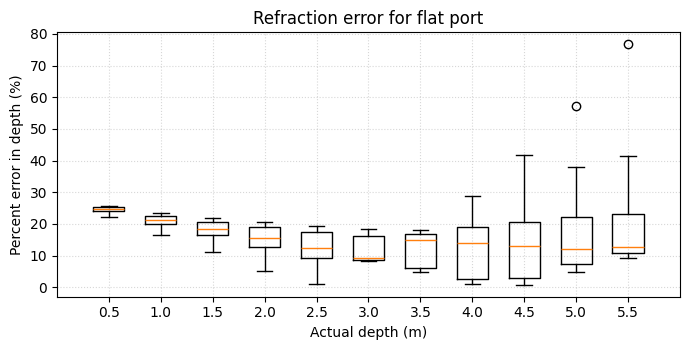

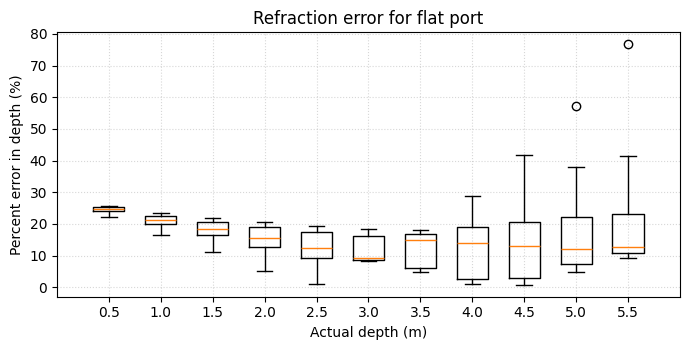

In [6]:
fig, ax = plt.subplots(figsize=(7.0, 3.6))
ax.boxplot(
    errors,
    positions=depths_m,
    widths=0.3,
    medianprops={"color": "C1"},
)
ax.set_xlabel("Actual depth (m)")
ax.set_ylabel("Percent error in depth (%)")
ax.set_xticks(depths_m)
ax.set_xticklabels([f"{d:.1f}" for d in depths_m])
ax.grid(True, linestyle=":", alpha=0.5)
ax.set_title("Refraction error for flat port")
fig.tight_layout()

save_paper_figure(fig, "refraction_error_box.pdf")
fig

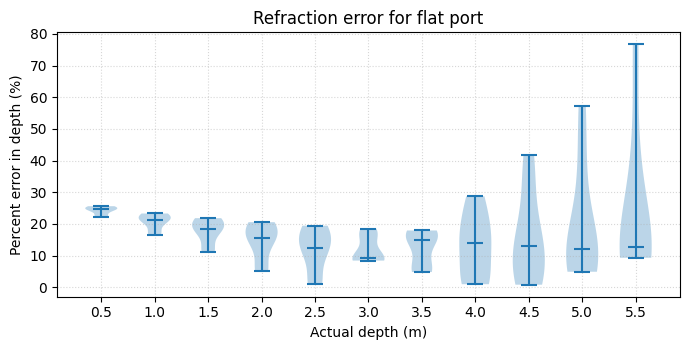

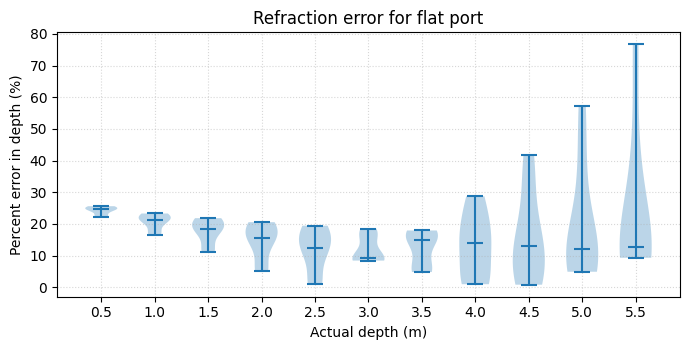

In [7]:
fig, ax = plt.subplots(figsize=(7.0, 3.6))
ax.violinplot(
    errors,
    positions=depths_m,
    widths=0.3,
    showmedians=True,
)
ax.set_xlabel("Actual depth (m)")
ax.set_ylabel("Percent error in depth (%)")
ax.set_xticks(depths_m)
ax.set_xticklabels([f"{d:.1f}" for d in depths_m])
ax.set_title("Refraction error for flat port")
ax.grid(True, linestyle=":", alpha=0.5)
fig.tight_layout()

save_paper_figure(fig, "refraction_error_violin.pdf")
fig

## Estimated vs. actual depth

Same simulation, plotted as the recovered depth $P_z^{\text{est}}$
versus the true depth. Each curve is one laser configuration; the
dashed line is $y = x$ (perfect recovery). Where a curve sits above
the diagonal the pinhole estimator overshoots; below, it undershoots.
Each configuration crosses the diagonal exactly once — the single
depth at which the refracted air-side ray happens to coincide with
the unrefracted pinhole ray.

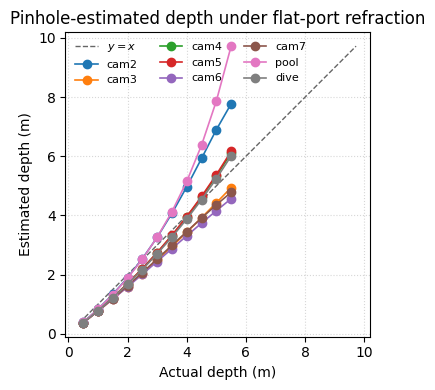

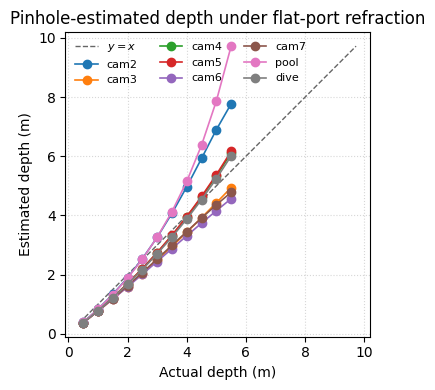

In [8]:
est_depths_mm = np.zeros_like(errors)
for i, (name, laser_origin, laser_direction) in enumerate(LASER_CONFIGURATIONS_MM):
    for j, w in enumerate(depths_mm):
        scale = (w - laser_origin[2]) / laser_direction[2]
        fish = laser_origin + scale * laser_direction
        v_air = solve_forward_projection(fish, port)
        est_depths_mm[i, j] = estimate_depth_pinhole(v_air, laser_origin, laser_direction)

est_depths_m = est_depths_mm / 1000.0

fig, ax = plt.subplots(figsize=(7.0, 4.0))

lo = min(depths_m.min(), est_depths_m.min())
hi = max(depths_m.max(), est_depths_m.max())
ax.plot([lo, hi], [lo, hi], color="0.4", linestyle="--", linewidth=1.0, label="$y = x$")

for (name, _, _), row in zip(LASER_CONFIGURATIONS_MM, est_depths_m):
    ax.plot(depths_m, row, marker="o", linewidth=1.2, label=name)

ax.set_xlabel("Actual depth (m)")
ax.set_ylabel("Estimated depth (m)")
ax.set_title("Pinhole-estimated depth under flat-port refraction")
ax.set_aspect("equal")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(ncol=3, fontsize=8, frameon=False)
fig.tight_layout()

save_paper_figure(fig, "refraction_estimated_vs_actual.pdf")
fig

## Per-configuration scatter (diagnostic)

The scatter plot from `plot_percenterrr.m` (scatter variant). Useful
for seeing that different laser poses cross zero at different depths:
each configuration has a single depth where the refracted ray happens
to coincide with the unrefracted pinhole ray, and the error grows on
either side.

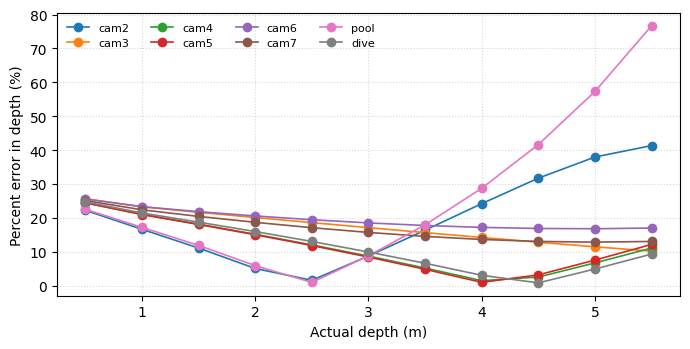

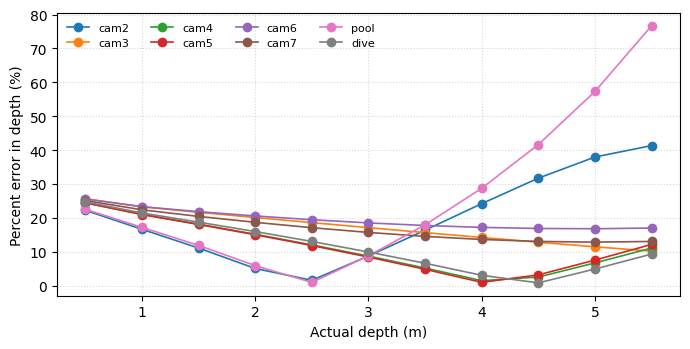

In [9]:
fig, ax = plt.subplots(figsize=(7.0, 3.6))
for (name, _, _), row in zip(LASER_CONFIGURATIONS_MM, errors):
    ax.plot(depths_m, row, marker="o", label=name, linewidth=1.2)
ax.set_xlabel("Actual depth (m)")
ax.set_ylabel("Percent error in depth (%)")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(ncol=4, fontsize=8, frameon=False)
fig.tight_layout()
fig

## Idealized reference camera

Same simulation, but using the canonical synthetic laser pose used by
the other notebooks in this repo (`baseline.ipynb`,
`max_distance.ipynb`, `laser_spot_path.ipynb`): a 4 cm lateral, 11 cm
vertical offset from the camera focal point, pointing essentially
along the optical axis. This is the laser pose the rest of the
system analysis assumes — its depth error under flat-port refraction
isolates how badly an uncorrected port would degrade the *ideal*
pipeline, before any per-unit calibration spread enters.

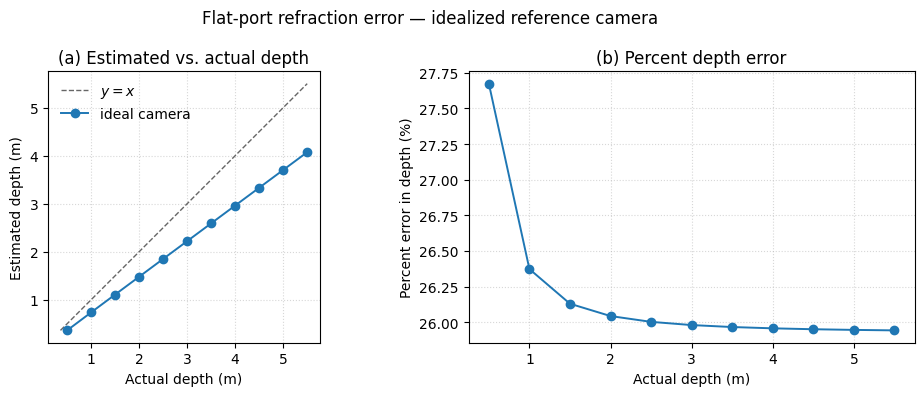

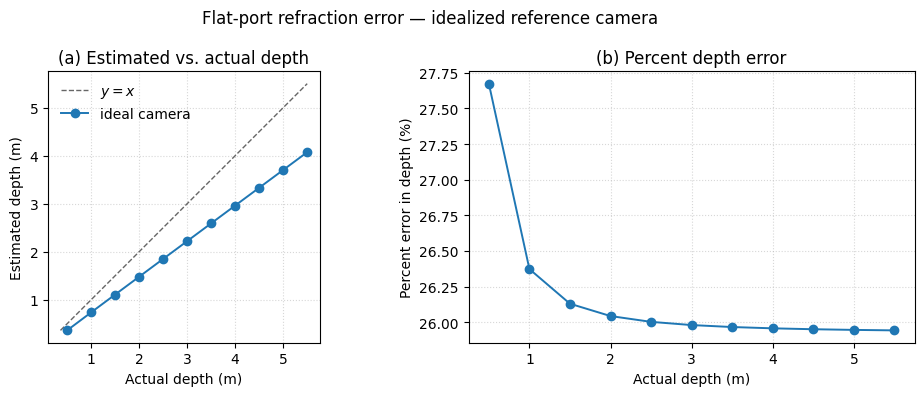

In [10]:
# Canonical synthetic laser pose from the other notebooks
# (defined in meters — convert to mm to match the FlatPort module).
ideal_laser_origin_mm = np.array([-0.04, -0.11, 0.0]) * 1000.0
ideal_laser_direction = np.array([1e-10, 1e-10, 1.0])

ideal_est_mm = np.zeros_like(depths_mm, dtype=float)
ideal_err_pct = np.zeros_like(depths_mm, dtype=float)
for j, w in enumerate(depths_mm):
    scale = (w - ideal_laser_origin_mm[2]) / ideal_laser_direction[2]
    fish = ideal_laser_origin_mm + scale * ideal_laser_direction
    v_air = solve_forward_projection(fish, port)
    ideal_est_mm[j] = estimate_depth_pinhole(v_air, ideal_laser_origin_mm, ideal_laser_direction)
    ideal_err_pct[j] = abs(ideal_est_mm[j] - fish[2]) / fish[2] * 100.0

ideal_est_m = ideal_est_mm / 1000.0

fig, (ax_est, ax_err) = plt.subplots(1, 2, figsize=(10.0, 4.0))

lo = min(depths_m.min(), ideal_est_m.min())
hi = max(depths_m.max(), ideal_est_m.max())
ax_est.plot([lo, hi], [lo, hi], color="0.4", linestyle="--", linewidth=1.0, label="$y = x$")
ax_est.plot(depths_m, ideal_est_m, marker="o", color="C0", linewidth=1.4, label="ideal camera")
ax_est.set_xlabel("Actual depth (m)")
ax_est.set_ylabel("Estimated depth (m)")
ax_est.set_title("(a) Estimated vs. actual depth")
ax_est.set_aspect("equal")
ax_est.grid(True, linestyle=":", alpha=0.5)
ax_est.legend(frameon=False)

ax_err.plot(depths_m, ideal_err_pct, marker="o", color="C0", linewidth=1.4)
ax_err.set_xlabel("Actual depth (m)")
ax_err.set_ylabel("Percent error in depth (%)")
ax_err.set_title("(b) Percent depth error")
ax_err.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("Flat-port refraction error — idealized reference camera")
fig.tight_layout()

save_paper_figure(fig, "refraction_ideal_camera.pdf")
fig